# Introduction to Unsupervised Learning

*The three core tasks and why they matter for air quality*

---
## 1. What is unsupervised learning?

In **supervised** learning, training data comes as pairs $(\mathbf{x}_i, y_i)$. The algorithm learns a function $f: \mathcal{X} \rightarrow \mathcal{Y}$ that maps inputs to targets.

In **unsupervised** learning, we only have $\mathbf{x}_i$. There is no $y$. The algorithm's job is to describe the *distribution* of the data — its clusters, its low-dimensional shape, its typical density — without any external label.

$$ \text{Supervised:} \quad \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_n, y_n)\} \longrightarrow f(\mathbf{x}) \approx y $$

$$ \text{Unsupervised:} \quad \{\mathbf{x}_1, \dots, \mathbf{x}_n\} \longrightarrow \text{structure in } \mathbf{x} $$

### A real-life analogy — sorting unfamiliar laundry

<div style="display: flex; flex-wrap: wrap; gap: 24px; align-items: flex-start;">
<div style="flex: 1 1 320px; max-width: 480px;">
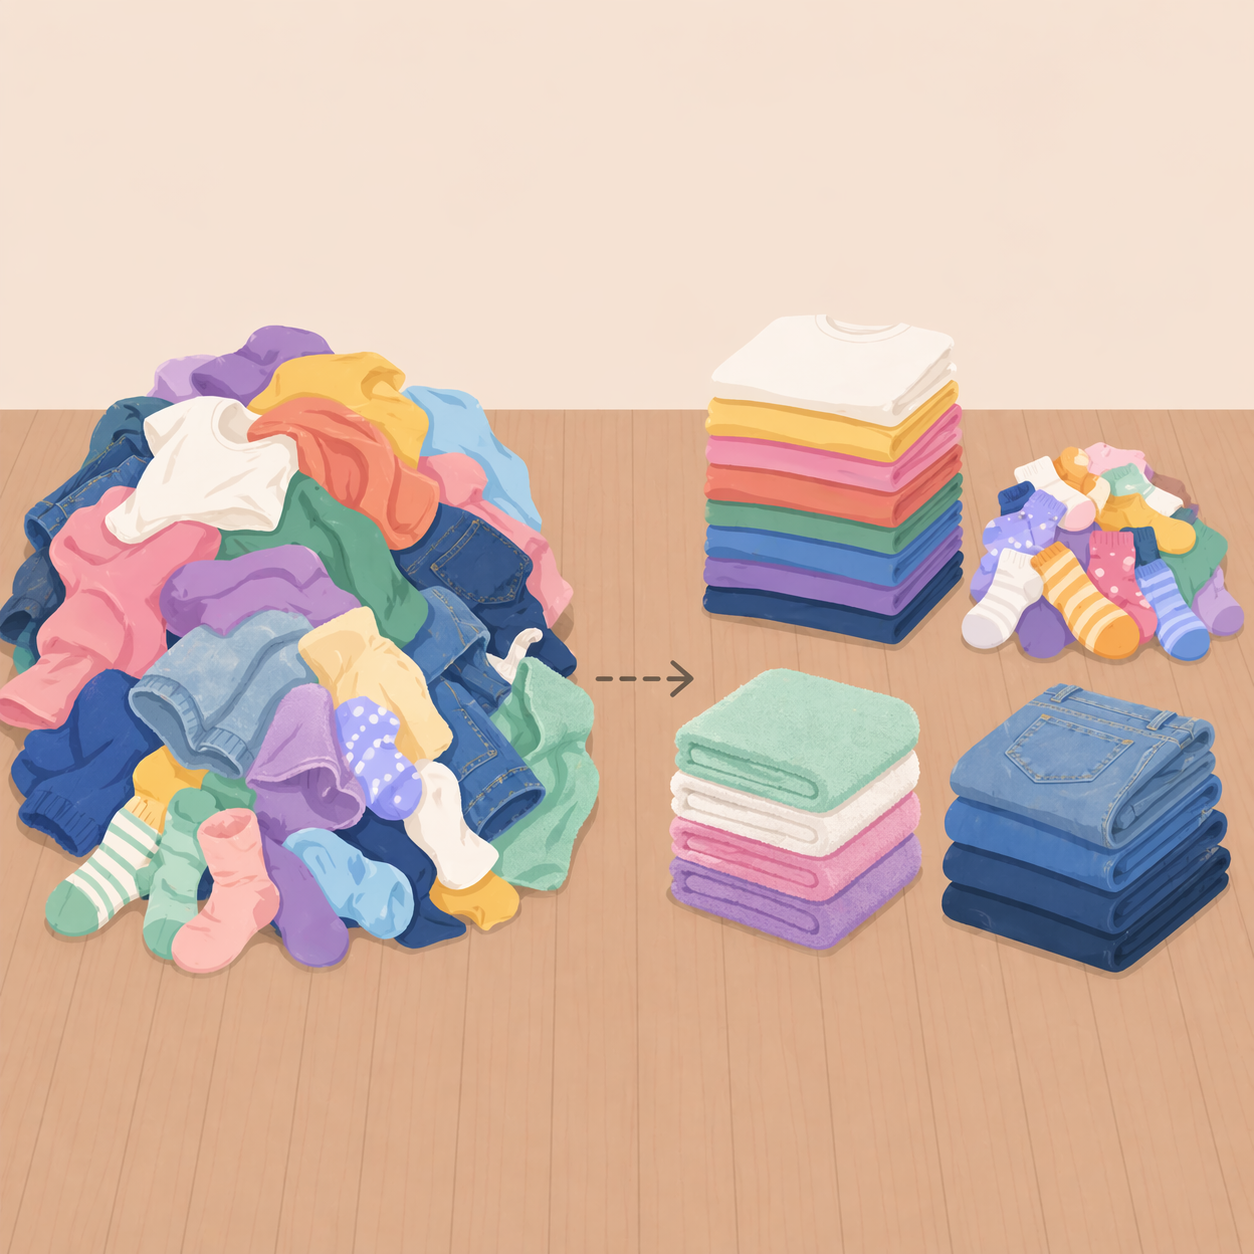
</div>
<div style="flex: 1 1 320px;">
<p>Imagine a friend drops off a huge bag of clothes and asks you to organise it. No one hands you a rulebook; no "right" categories are announced. Yet within minutes you start forming piles — not by a single obvious feature but by <strong>combinations of many</strong>: colour, fabric, size, thickness, who might wear them, how they fold. You simply notice that some items belong together and others clearly don't.</p>
<p>Two things are worth spelling out, because they map directly onto unsupervised learning:</p>
<ul>
<li><strong>The structure comes from the data, not from instructions.</strong> You are not imposing categories; you are <em>reading them off</em> the pile.</li>
<li><strong>There is no single right answer.</strong> A roommate coming in later might sort the same pile by season instead of type, or by owner instead of fabric — and both groupings can be equally defensible.</li>
</ul>
<p>That instinct — <em>finding structure in something unlabeled, using many features at once, with no guarantee of a unique correct grouping</em> — is exactly what unsupervised learning does. The only difference is that the algorithm doesn't know the items are socks or towels; it sees only numbers, and all it can observe is which points <em>look similar</em> and which don't.</p>
</div>
</div>

### Why labels are so often missing in practice

Textbook examples make it look as if labels just *exist*. In real projects they usually don't — or there are nowhere near enough of them. Some of the most common reasons:

- **The categories themselves are unknown.** We often don't yet know what the "right" groups are — *discovering them* is the whole point. You can't label what hasn't been named.
- **Labelling is time-consuming.** Tagging large datasets by hand can take days or weeks of attentive work — a cost most projects cannot absorb.
- **Many tasks require domain expertise.** Reliably labelling a medical image, a seismic trace, or a piece of legal text calls for a domain expert — and expert time is scarce and expensive.
- **Scale makes it infeasible.** Real datasets can easily reach millions of records, and many of them keep growing in real time — far faster than humans can annotate. Past a certain volume, hand-labelling is simply off the table.
- **The answer we would want cannot be measured.** In some problems, the label we are looking for simply does not exist in the data itself. We can measure how much PM2.5 is in the air, for example, but not how much of it came from traffic, heating, or industry.
- **Experts disagree.** Two specialists can assign the same observation to different categories. When there is no single right answer, the concept of "label" itself becomes fuzzy.
- **Privacy or legal constraints.** Some data (health records, personal location traces) cannot be shared with annotators at all.

Whenever any of these apply, unsupervised learning is the natural first tool. It extracts structure *before* any labels exist — and often reveals exactly which categories would have been worth labelling in the first place.

### Supervised vs. unsupervised at a glance

| Aspect | Supervised | Unsupervised |
|---|---|---|
| Training data | (**X**, **y**) | **X** only |
| Goal | Predict **y** from **x** | Discover structure in **x** |
| Typical tasks | Classification, regression | Clustering, dim. reduction, anomaly detection |
| Evaluation | Accuracy, RMSE, F1, … | Mostly indirect: interpretability, silhouette, stability |
| Air-quality example | *Predict tomorrow's PM2.5 from today's weather* | *Group hourly records into pollution regimes* |

---
## 2. The three core tasks

Almost every unsupervised method falls into one of three families:

| Task | One-line definition | Typical question |
|---|---|---|
| **Clustering** | Partition points into groups of similar items | *What goes with what?* |
| **Dimensionality reduction** | Project data into fewer dimensions while preserving information | *What is the "shape" of the data?* |
| **Anomaly detection** | Flag points that don't look like the rest | *Who doesn't belong?* |

Let's look at each with an analogy and a tiny visual demo.

### 2.1 Clustering — *"what goes with what"*

**Idea.** Put similar points into the same group. "Similar" usually means *close* in some distance metric.

**Analogy — the wedding reception.** You are a plus-one at a wedding where you know nobody. Looking around the room you can nevertheless spot rough groupings: the bride's family dressed formally near the head table, the groom's university friends in loud laughter near the bar, work colleagues chatting quietly by the window. No one wears a name tag saying "Group A", yet the clusters are obvious from proximity and behaviour. Clustering algorithms do the same on numerical data.

**Tiny demo.** Below we generate a synthetic 2-D dataset that *does* contain three hidden groups, and simply plot it. Before clustering, imagine you are seeing only the grey points — could you guess how many groups there are?

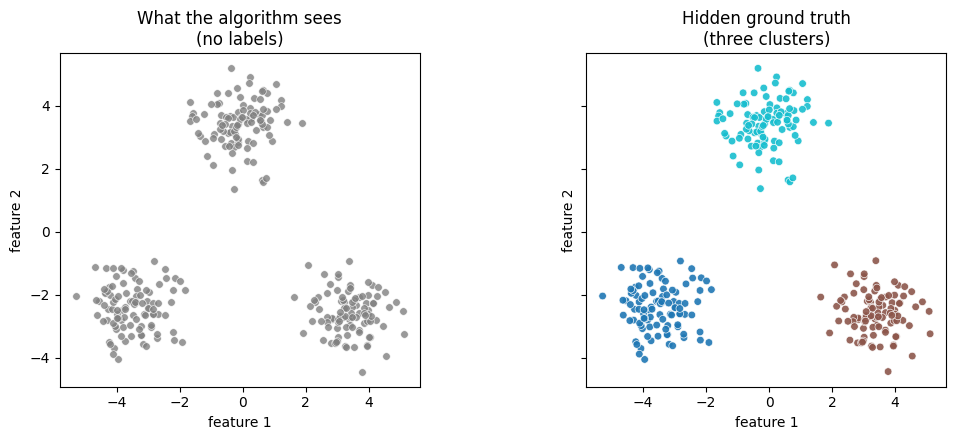

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

rng = np.random.default_rng(0)

centers = [(-3.5, -2.5), (3.5, -2.5), (0, 3.5)]   # clearly separated, not too spread out
X, y_true = make_blobs(
    n_samples=300, centers=centers, cluster_std=0.7,
    random_state=0,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], s=30, color="gray",
                alpha=0.8, edgecolor="white", linewidth=0.5)
axes[0].set_title("What the algorithm sees\n(no labels)")
axes[0].set_xlabel("feature 1"); axes[0].set_ylabel("feature 2")

axes[1].scatter(X[:, 0], X[:, 1], c=y_true, s=30, cmap="tab10",
                alpha=0.9, edgecolor="white", linewidth=0.5)
axes[1].set_title("Hidden ground truth\n(three clusters)")
axes[1].set_xlabel("feature 1"); axes[1].set_ylabel("feature 2")

for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

The point of clustering is to recover something close to the right-hand picture, *starting from only the grey points on the left.* In Notebook 3 we'll do exactly this on real pollutant data — and interpret the resulting clusters as pollution regimes.

### 2.2 Dimensionality reduction — *"keep the story, drop the noise"*

**Idea.** High-dimensional data is hard to visualise and often contains a lot of redundancy (correlated features). Dimensionality reduction projects the data into fewer dimensions while keeping as much *variance* (information) as possible.

**Analogy — the one-paragraph biography.** A 500-page biography of a scientist cannot be reproduced in a paragraph, yet a well-written paragraph still captures the *shape* of the life: the main chapters, the big discoveries, the turning points. **Principal Component Analysis (PCA)** does this for numerical data: it finds a small number of directions along which the data varies most, and discards the rest as "small detail".

**Tiny demo — two thermometers, one room.** Imagine two temperature sensors placed side by side in the same room. Each one measures essentially the same ambient temperature, plus a tiny amount of independent noise. The two readings give us *two numbers* per timestep — but they carry only *one* real piece of information (the room temperature). PCA recognises this: it finds one direction along which nearly all the variation lies (the "true temperature" axis), and a second, tiny direction which is just measurement noise. Dropping the second direction costs us almost nothing — we throw away noise, not signal.

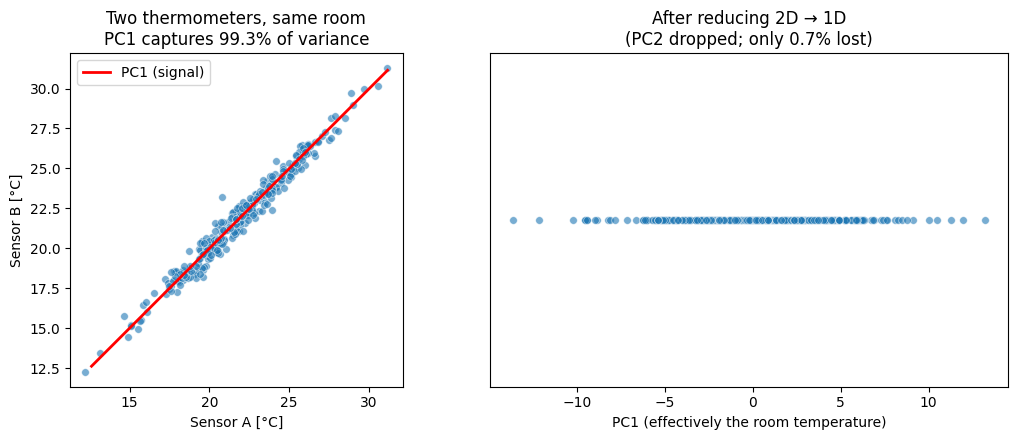

In [2]:
from sklearn.decomposition import PCA

# Two thermometers side-by-side measuring the same ambient temperature.
n = 300
true_temp = rng.normal(loc=22.0, scale=3.0, size=n)     # true room temperature [deg C]
sensor_A  = true_temp + rng.normal(scale=0.4, size=n)   # independent noise per sensor
sensor_B  = true_temp + rng.normal(scale=0.4, size=n)
X = np.column_stack([sensor_A, sensor_B])

pca = PCA(n_components=2).fit(X)
X_1d = pca.transform(X)[:, 0]            # projection onto PC1 only
var_pc1, var_pc2 = pca.explained_variance_ratio_

# PC1 axis line for overlay
mean = X.mean(axis=0)
pc1 = pca.components_[0]
span = 3.0 * np.sqrt(pca.explained_variance_[0])
line_x = [mean[0] - span * pc1[0], mean[0] + span * pc1[0]]
line_y = [mean[1] - span * pc1[1], mean[1] + span * pc1[1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(X[:, 0], X[:, 1], s=30, alpha=0.6,
                edgecolor="white", linewidth=0.5)
axes[0].plot(line_x, line_y, color="red", linewidth=2, label="PC1 (signal)")
axes[0].set_title(f"Two thermometers, same room\nPC1 captures {var_pc1*100:.1f}% of variance")
axes[0].set_xlabel("Sensor A [\u00b0C]"); axes[0].set_ylabel("Sensor B [\u00b0C]")
axes[0].set_aspect("equal"); axes[0].legend(loc="upper left")

axes[1].scatter(X_1d, np.zeros_like(X_1d), s=30, alpha=0.6,
                edgecolor="white", linewidth=0.5)
axes[1].set_yticks([])
axes[1].set_title(f"After reducing 2D \u2192 1D\n(PC2 dropped; only {var_pc2*100:.1f}% lost)")
axes[1].set_xlabel("PC1 (effectively the room temperature)")

plt.tight_layout(); plt.show()

The left panel shows that the two sensors are nearly perfectly correlated — every point lies close to the red PC1 line. The right panel shows what remains after dropping PC2: a 1-D version of the data that preserves almost all of the information. **We went from 2 numbers to 1 with negligible loss.**

In Notebook 2 we apply PCA to eleven air-quality and meteorological variables and see that just 2–3 components capture most of what really varies — and those components have physical interpretations.

### 2.3 Anomaly detection — *"who doesn't belong"*

**Idea.** Most points look normal; a few don't. Anomaly-detection methods formalise this by measuring how *isolated* a point is — by distance, by density, or by reconstruction error.

**Analogy — the credit-card call.** The bank doesn't know in advance which transactions are fraud. It learns your *normal* pattern — coffee shops in Zagreb, groceries on Saturdays — and raises the alarm when a \$4 000 purchase appears at 3 AM in another country. No label needed; the point simply doesn't match the distribution.

**Tiny demo.** Two dense clusters of "normal" points, plus a handful of deliberately weird points scattered far from both.

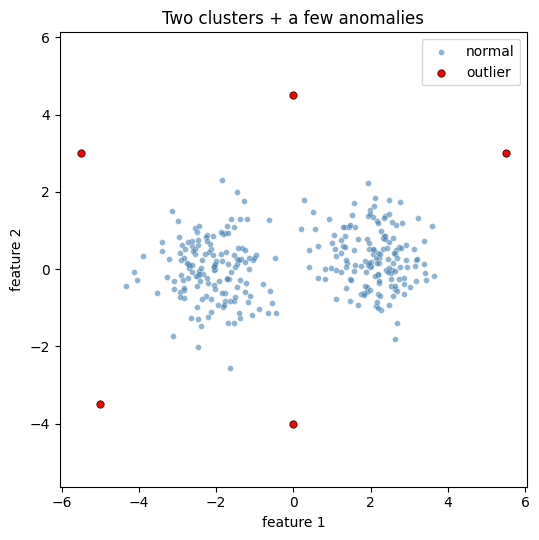

In [3]:
# Two dense clusters (the 'normal' data)
c1 = rng.normal(loc=(-2.0, 0.0), scale=0.8, size=(150, 2))
c2 = rng.normal(loc=( 2.0, 0.3), scale=0.7, size=(150, 2))
normal = np.vstack([c1, c2])

# A handful of outliers placed away from both clusters
outliers = np.array([
    [ 0.0,  4.5],
    [ 0.0, -4.0],
    [ 5.5,  3.0],
    [-5.5,  3.0],
    [-5.0, -3.5],
])

X = np.vstack([normal, outliers])
is_outlier = np.array([False] * len(normal) + [True] * len(outliers))

plt.figure(figsize=(5.5, 5.5))
plt.scatter(X[~is_outlier, 0], X[~is_outlier, 1], s=18, alpha=0.6,
            color="steelblue", edgecolor="white", linewidth=0.3, label="normal")
plt.scatter(X[ is_outlier, 0], X[ is_outlier, 1], s=28, color="red",
            edgecolor="black", linewidth=0.5, label="outlier")
plt.legend(); plt.title("Two clusters + a few anomalies")
plt.xlabel("feature 1"); plt.ylabel("feature 2")
plt.axis("equal"); plt.tight_layout(); plt.show()

You can spot the red points by eye. In Notebook 4 we use **DBSCAN**, a density-based algorithm, to flag **sensor readings** that differ from the bulk of the data — a signature of faulty instruments or unusual pollution events.

---
## 3. Why unsupervised learning for air quality?

Environmental monitoring data is almost tailor-made for unsupervised methods. Here is why:

- **Labels are rare and expensive.** No one hand-annotates every hour of a four-year PM2.5 time series as *"traffic-dominated"* or *"long-range dust transport"*. Unsupervised methods can surface those regimes directly from the numbers.
- **Sensors fail silently.** A stuck analyser can keep producing values that look plausible — right order of magnitude, right variance — yet diverge systematically from its neighbours. Density- or distance-based anomaly detection spots this without needing a fault label.
- **Pollutants are correlated.** PM2.5 and PM10 move together, CO and NO₂ spike during rush hour, O₃ tracks solar radiation. Eleven raw variables often carry only 3–4 independent degrees of freedom — a textbook case for PCA.
- **Sources are hidden mixtures.** At a receptor we measure a *mixture* of contributions from traffic, heating, industry, secondary aerosols, and dust. The *sources themselves* are never observed directly — they have to be inferred. That inference is inherently unsupervised.

### Concrete air-quality questions and the methods that answer them

| Unsupervised task | Concrete air-quality question | Method (used in NB) |
|---|---|---|
| Clustering | *What recurring pollution "moods" does a city have?* e.g. clean-&-windy, traffic-rush, winter-heating, dust-episode | K-Means (NB3) |
| Dimensionality reduction | *Can I summarise a dozen pollutant + meteo variables in 2–3 numbers for visualisation and downstream modelling?* | PCA (NB2) |
| Anomaly detection | *Which hours at a station look nothing like the rest of the record?* — candidate sensor faults or unusual events | DBSCAN (NB4) |
| Source apportionment | *Given a PCA component loading highly on NO₂, CO and PM2.5 — is that a "traffic" factor?* | Interpretation of PCA + clusters (NB4) |

Every one of these questions will become a concrete, runnable experiment in the next three notebooks — applied to a real multi-year Beijing air-quality record introduced in Section&nbsp;5.

---
## 4. Pitfalls and things to keep in mind

Unsupervised learning is powerful but unforgiving — there is no test-set accuracy to tell you your result is wrong. A few habits that will save you later:

1. **Scale your features.** Almost every unsupervised algorithm uses distances. Pressure in hPa is around 1000, wind speed in m/s is around 2, PM2.5 in µg/m³ is around 50. Without standardisation, whatever variable has the largest numeric scale simply dominates the result.
2. **There is no single "right" answer.** Different methods, different hyperparameters, different random seeds will give different clusters. Evaluate through *interpretability*, *stability*, and *downstream usefulness* — not a single metric.
3. **The number of clusters is a modelling choice.** K-Means needs $k$ up front. We'll pick it using the elbow method and silhouette analysis in NB3.
4. **Statistical directions are not causes.** A PCA component that lights up on NO₂, CO and PM2.5 *looks like* traffic, but is a *hypothesis*. Cross-check with rush-hour timing, wind direction, proximity to roads — the science, not just the numbers.
5. **Missing data matters.** Environmental datasets are full of gaps. Decide (and document) your policy: drop, impute, interpolate — each has consequences for what clusters and components mean.

### Why scaling matters — a 30-second demonstration

Consider three observations of the atmosphere, each described by two features on very different numeric scales:

- **A** — a *typical hour*: wind = 2&nbsp;m/s, CO = 1500&nbsp;µg/m³
- **C** — *another typical hour* with a minor CO swing: wind = 2&nbsp;m/s, CO = 2000&nbsp;µg/m³
- **B** — a *stormy hour*: wind = 10&nbsp;m/s, CO = 1500&nbsp;µg/m³

Physically, **A and C are two similar, routine hours** — calm wind, small day-to-day CO variation. **B is the outlier** — a 10&nbsp;m/s wind is rare in Beijing. Does a raw Euclidean distance agree with that reading, or does the feature with the bigger numeric scale drown out the other?

In [4]:
# Typical magnitudes for wind [m/s] and CO [ug/m3] (roughly matches Aotizhongxin)
wind_std, CO_std  = 1.0, 1200.0      # feature standard deviations
wind_mean, CO_mean = 2.0, 1500.0

A = np.array([ 2.0, 1500.0])    # typical hour
C = np.array([ 2.0, 2000.0])    # another typical hour  (CO 500 ug/m^3 higher, routine)
B = np.array([10.0, 1500.0])    # stormy hour  (wind 8 m/s above normal)

# --- Raw Euclidean distance (no scaling) ---
d_AB_raw = np.linalg.norm(A - B)
d_AC_raw = np.linalg.norm(A - C)

# --- Distance after bringing both features to mean 0, std 1 ---
def z(p):
    return np.array([(p[0] - wind_mean) / wind_std,
                     (p[1] - CO_mean)   / CO_std])

d_AB_scl = np.linalg.norm(z(A) - z(B))
d_AC_scl = np.linalg.norm(z(A) - z(C))

print(f"{'':22}{'wind [m/s]':>12}{'CO [ug/m^3]':>15}")
print(f"{'A  (typical hour)':22}{A[0]:>12.1f}{A[1]:>15.0f}")
print(f"{'C  (typical hour)':22}{C[0]:>12.1f}{C[1]:>15.0f}")
print(f"{'B  (storm, outlier)':22}{B[0]:>12.1f}{B[1]:>15.0f}")

print(f"\nRaw distances (no scaling):")
print(f"   d(A, C) = {d_AC_raw:>7.1f}    <- CO   differs by 500     (two similar routine hours)")
print(f"   d(A, B) = {d_AB_raw:>7.1f}    <- wind differs by 8 m/s   (the actual outlier)")
print(f"   The routine day C looks ~{d_AC_raw/d_AB_raw:.0f}x farther from A than the storm B does —"
       " pure artefact of the numeric scale.")

print(f"\nScaled distances (z-scored, mean 0 / std 1 per feature):")
print(f"   d(A, C) = {d_AC_scl:>7.2f}    <- CO   is {d_AC_scl:.2f} std devs away (A and C are close)")
print(f"   d(A, B) = {d_AB_scl:>7.2f}    <- wind is {d_AB_scl:.1f} std devs away  (B correctly flagged)")
print(f"   Now B is ~{d_AB_scl/d_AC_scl:.0f}x farther from A than C — physical intuition restored.")

                        wind [m/s]    CO [ug/m^3]
A  (typical hour)              2.0           1500
C  (typical hour)              2.0           2000
B  (storm, outlier)           10.0           1500

Raw distances (no scaling):
   d(A, C) =   500.0    <- CO   differs by 500     (two similar routine hours)
   d(A, B) =     8.0    <- wind differs by 8 m/s   (the actual outlier)
   The routine day C looks ~62x farther from A than the storm B does — pure artefact of the numeric scale.

Scaled distances (z-scored, mean 0 / std 1 per feature):
   d(A, C) =    0.42    <- CO   is 0.42 std devs away (A and C are close)
   d(A, B) =    8.00    <- wind is 8.0 std devs away  (B correctly flagged)
   Now B is ~19x farther from A than C — physical intuition restored.


**Reading the output.** On the raw scale, a 500&nbsp;µg/m³ CO bump contributes roughly **sixty times** more to the distance than an 8&nbsp;m/s wind swing — purely because CO is measured in much larger numeric units. Any distance-based algorithm (K-Means, DBSCAN, PCA via its covariance) would then treat **C as the outlier** and essentially ignore the storm. After standardising, each feature is measured in *standard deviations from its own mean*, so an 8&nbsp;&sigma; wind swing outweighs a modest &lt; 0.5&nbsp;&sigma; CO bump — exactly as physical intuition requires. The conclusion about "which point is the outlier" **completely flips**.

**Always standardise before PCA, K-Means, or DBSCAN.**

---
## 5. Preview — the dataset we'll use from Notebook 2

The **Beijing Multi-Site Air-Quality dataset** contains hourly measurements from **12 monitoring stations** across Beijing between **1 March 2013 and 28 February 2017** — roughly **35 000 hours × 12 stations ≈ 420 000 records**. On disk the CSV files are named `PRSA_Data_*.csv` after the journal where the original analysis was published (*Proceedings of the Royal Society A*); that prefix is why you will see "PRSA" in filenames and code paths throughout the module.

Each record has:

| Group | Variables |
|---|---|
| Time | year, month, day, hour |
| Pollutants | PM2.5, PM10, SO₂, NO₂, CO, O₃ |
| Meteorology | TEMP, PRES, DEWP, RAIN, WSPM (wind speed), wd (wind direction) |
| Context | station |

This is *rich* multivariate data with strong correlations, clear daily and seasonal cycles, episodic pollution events, and occasional sensor glitches — a near-perfect playground for PCA, clustering, and anomaly detection.

> **Reference.** Zhang et al., *Cautionary tales on air-quality improvement in Beijing*, Proc. Royal Soc. A, 2017. Publicly available via the UCI Machine Learning Repository: [archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data).

---
## Recap

- **Unsupervised learning** finds structure in data without labels.
- Three core tasks: **clustering** (what goes with what), **dimensionality reduction** (keep the story, drop the noise), **anomaly detection** (who doesn't belong).
- Environmental monitoring data is an ideal application: labels are rare, pollutants are correlated, sources are hidden mixtures, and sensors fail silently.
- Always **standardise**, always **validate with domain knowledge**, never trust a single number.

### Check your understanding

1. You want to know *which factors most strongly drive variation in a sensor network of 20 correlated pollutants*. Which unsupervised task is this?
2. You suspect one of 12 stations reports PM2.5 values that drift systematically low. Which task?
3. You want to discover *how many distinct "pollution regimes"* a city experiences over a year. Which task?
4. Why is it dangerous to run K-Means on raw (unscaled) pollutant + meteorology data?

*(Answers: 1 — dimensionality reduction (PCA). 2 — anomaly detection. 3 — clustering. 4 — variables with large numeric scale (e.g. pressure ≈ 1000 hPa) will dominate the distance and hide real structure in smaller-scale variables.)*

---

### Next up

**Notebook 2 — Principal Component Analysis on the Beijing air-quality dataset.** We load the real data, standardise it, apply PCA, and see how many components we really need — and what each one means.